# 911 Emergency Calls Analysis: Patterns, Trends, and Operational Insights

## Business Context
Emergency response teams rely on historical call data to allocate resources,
identify high-risk areas, and anticipate peak demand periods. This analysis
examines 911 call records to uncover temporal, geographic, and categorical
patterns that can inform staffing and emergency preparedness decisions.


## Data Description
The dataset contains records of 911 emergency calls, including:
- Call location (latitude, longitude, zipcode, township)
- Call description and category
- Timestamp of the call

Each row represents a single emergency call.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv('911.csv')
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99492 entries, 0 to 99491
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   lat        99492 non-null  float64
 1   lng        99492 non-null  float64
 2   desc       99492 non-null  object 
 3   zip        86637 non-null  float64
 4   title      99492 non-null  object 
 5   timeStamp  99492 non-null  object 
 6   twp        99449 non-null  object 
 7   addr       98973 non-null  object 
 8   e          99492 non-null  int64  
dtypes: float64(3), int64(1), object(5)
memory usage: 6.8+ MB


,lat,lng,desc,zip,title,timeStamp,twp,addr,e
0,40.297876,-75.581294,REINDEER CT & DEAD END; NEW HANOVER; Station ...,19525.0,EMS: BACK PAINS/INJURY,2015-12-10 17:40:00,NEW HANOVER,REINDEER CT & DEAD END,1
1,40.258061,-75.264680,BRIAR PATH & WHITEMARSH LN; HATFIELD TOWNSHIP...,19446.0,EMS: DIABETIC EMERGENCY,2015-12-10 17:40:00,HATFIELD TOWNSHIP,BRIAR PATH & WHITEMARSH LN,1
2,40.121182,-75.351975,HAWS AVE; NORRISTOWN; 2015-12-10 @ 14:39:21-St...,19401.0,Fire: GAS-ODOR/LEAK,2015-12-10 17:40:00,NORRISTOWN,HAWS AVE,1
3,40.116153,-75.343513,AIRY ST & SWEDE ST; NORRISTOWN; Station 308A;...,19401.0,EMS: CARDIAC EMERGENCY,2015-12-10 17:40:01,NORRISTOWN,AIRY ST & SWEDE ST,1
4,40.251492,-75.603350,CHERRYWOOD CT & DEAD END; LOWER POTTSGROVE; S...,NaN,EMS: DIZZINESS,2015-12-10 17:40:01,LOWER POTTSGROVE,CHERRYWOOD CT & DEAD END,1


### Initial Observations
- Dataset contains a large volume of time-stamped emergency calls
- Some location fields contain missing values
- Call descriptions embed both category and subcategory information


In [3]:
df['zip'].value_counts().head()

zip
19401.0    6979
19464.0    6643
19403.0    4854
19446.0    4748
19406.0    3174
Name: count, dtype: int64

In [4]:
df['twp'].value_counts().head()

twp
LOWER MERION    8443
ABINGTON        5977
NORRISTOWN      5890
UPPER MERION    5227
CHELTENHAM      4575
Name: count, dtype: int64

In [5]:
df['title'].nunique()

110

## Creating new features

### Call Categorization
The call title contains both category and subcategory information.
Extracting the primary reason allows aggregation and trend analysis
across emergency types.


In [6]:
df['reason']=df['title'].apply(lambda x:x.split(':')[0])
df['reason']

0            EMS
1            EMS
2           Fire
3            EMS
4            EMS
          ...   
99487    Traffic
99488    Traffic
99489        EMS
99490        EMS
99491    Traffic
Name: reason, Length: 99492, dtype: object

### Insight
EMS-related calls dominate the dataset, indicating medical emergencies
are the primary driver of 911 demand. This has implications for ambulance
availability and medical staffing.


In [7]:
df['reason'].value_counts()

reason
EMS        48877
Traffic    35695
Fire       14920
Name: count, dtype: int64

[]

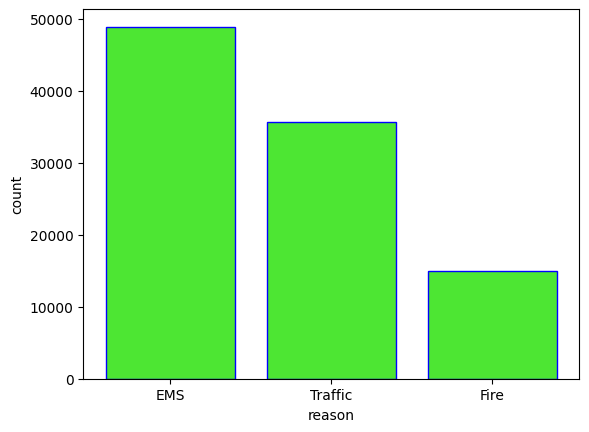

In [8]:
# sns.countplot(df,y='reason',hue='reason',palette='rainbow',legend=False,fill=False,orient='v')
sns.countplot(df,x='reason',hue='reason',palette='rainbow',saturation=1,order=['EMS','Traffic','Fire'],facecolor=[.3,.9,.2,1],
             lw=1,edgecolor='blue')

plt.plot()

In [9]:
df['timeStamp'].dtype.name

'object'

### Time-Based Features
Emergency demand varies significantly by time of day, weekday, and month.
Extracting these features enables temporal trend analysis.


In [10]:
# default recognized format : YYYY-MM-DD

df['timeStamp']=pd.to_datetime(df['timeStamp'])

In [11]:
df['timeStamp']

0       2015-12-10 17:40:00
1       2015-12-10 17:40:00
2       2015-12-10 17:40:00
3       2015-12-10 17:40:01
4       2015-12-10 17:40:01
                ...        
99487   2016-08-24 11:06:00
99488   2016-08-24 11:07:02
99489   2016-08-24 11:12:00
99490   2016-08-24 11:17:01
99491   2016-08-24 11:17:02
Name: timeStamp, Length: 99492, dtype: datetime64[ns]

In [12]:
time=df['timeStamp'][0]
time.day_of_week

3

In [13]:
df['Hour']=df['timeStamp'].apply(lambda x:x.hour)
df['Month']=df['timeStamp'].apply(lambda x:x.month)
df['Day Of Week']=df['timeStamp'].apply(lambda x:x.day_of_week)


In [14]:
df['Day Of Week']=df['Day Of Week'].map({0:'Mon',1:'Tue',2:'Wed',3:'Thu',4:'Fri',5:'Sat',6:'Sun'})

In [15]:
df['Day Of Week'].value_counts()

Day Of Week
Tue    15150
Wed    14879
Fri    14833
Mon    14680
Thu    14478
Sat    13336
Sun    12136
Name: count, dtype: int64

### Weekly Pattern
Call volume remains relatively stable across weekdays, with a slight
increase on weekends, particularly for EMS calls.


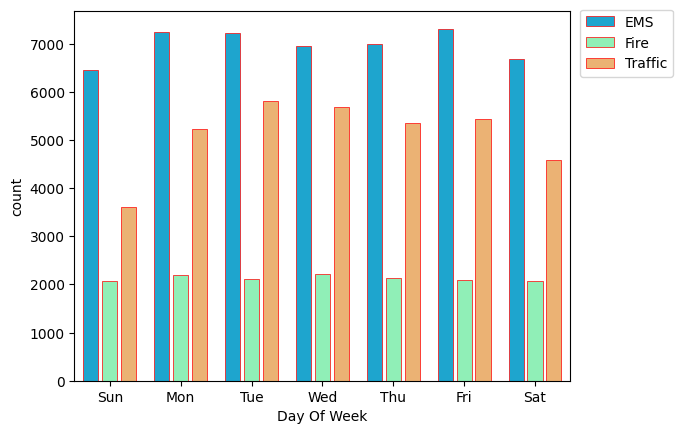

In [16]:
sns.countplot(data=df,x='Day Of Week',palette='rainbow',hue='reason',order=['Sun','Mon','Tue','Wed','Thu','Fri','Sat'],
             edgecolor='red',lw=0.5,width=0.8,gap=0.2,stat='count')
plt.legend(loc=(1.02,0.823))

### Seasonal Trend
Emergency calls show seasonal variation, with higher volumes during
certain months, potentially linked to weather and population behavior.


<Axes: xlabel='Month', ylabel='count'>

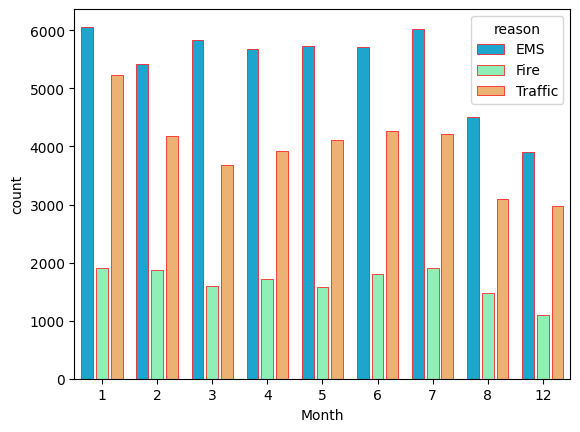

In [17]:
sns.countplot(data=df,x='Month',palette='rainbow',hue='reason',
             edgecolor='red',lw=0.5,width=0.8,gap=0.2,stat='count')

In [18]:
groupby_month=df.groupby(by='Month').count()
groupby_month.head()

,lat,lng,desc,zip,title,timeStamp,twp,addr,e,reason,Hour,Day Of Week
Month,,,,,,,,,,,,
1,13205,13205,13205,11527,13205,13205,13203,13096,13205,13205,13205,13205
2,11467,11467,11467,9930,11467,11467,11465,11396,11467,11467,11467,11467
3,11101,11101,11101,9755,11101,11101,11092,11059,11101,11101,11101,11101
4,11326,11326,11326,9895,11326,11326,11323,11283,11326,11326,11326,11326
5,11423,11423,11423,9946,11423,11423,11420,11378,11423,11423,11423,11423


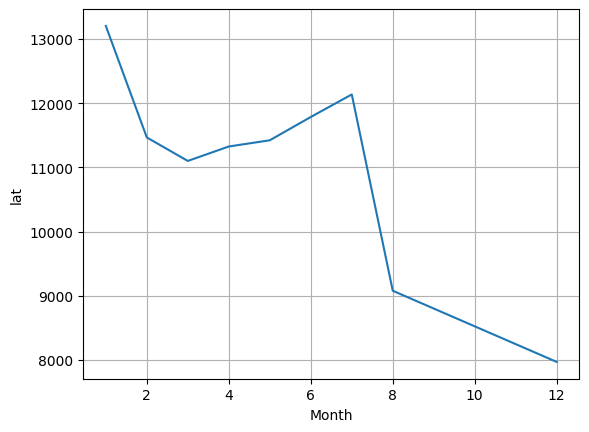

In [19]:
sns.lineplot(data=groupby_month,x='Month',y='lat',)
plt.grid()

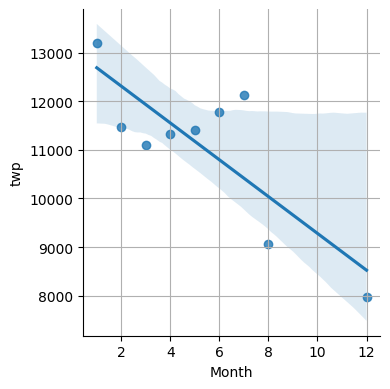

In [20]:
sns.lmplot(data=groupby_month.reset_index(),x='Month',y='twp',height=4)
plt.grid()

In [21]:
df['Date']=df['timeStamp'].apply(lambda x:x.date())
df['Date'].value_counts()

Date
2016-01-23    913
2016-02-24    679
2016-01-24    662
2016-01-12    588
2016-04-03    586
             ... 
2016-02-07    255
2016-03-20    244
2016-05-01    140
2016-08-24    132
2015-12-10    115
Name: count, Length: 259, dtype: int64

In [22]:
groupby_date=df.groupby(by='Date').count()

<Axes: xlabel='Date', ylabel='lat'>

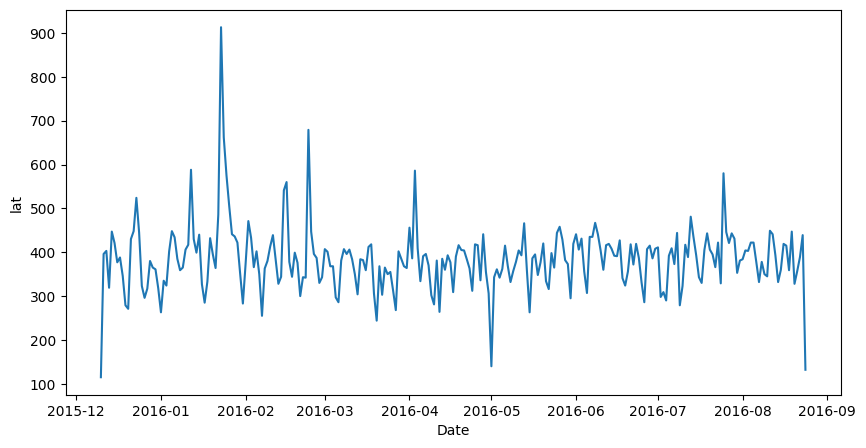

In [23]:
plt.figure(figsize=(10,5))
sns.lineplot(groupby_date,x='Date',y='lat')

In [24]:
ems_df=df[df['reason']=='EMS']
fire_df=df[df['reason']=='Fire']
traffic_df=df[df['reason']=='Traffic']

ems_groupby_date=ems_df.groupby('Date').count()
fire_groupby_date=fire_df.groupby('Date').count()
traffic_groupby_date=traffic_df.groupby('Date').count()

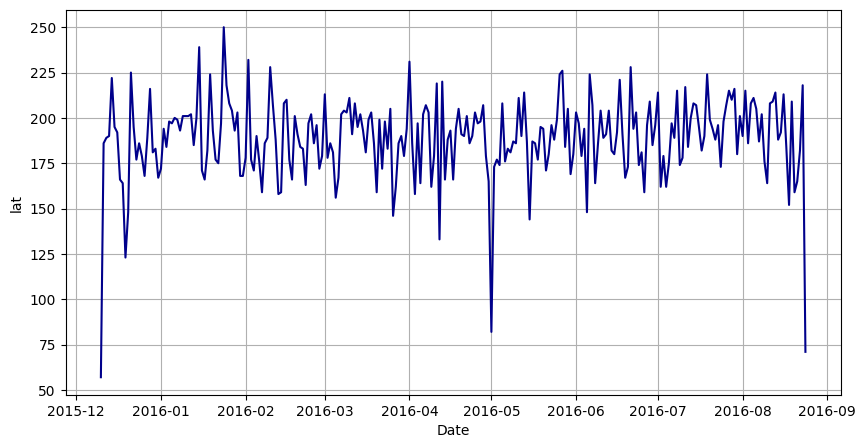

In [25]:
plt.figure(figsize=(10,5))
sns.lineplot(ems_groupby_date,x='Date',y='lat',color='darkblue')
plt.grid()

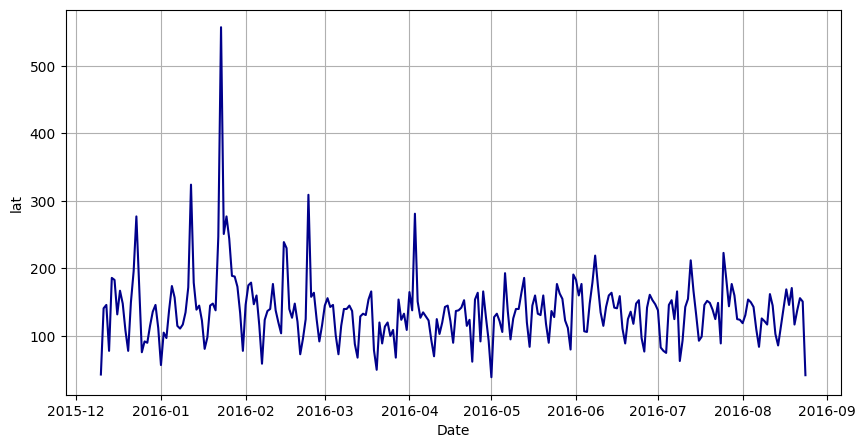

In [26]:
plt.figure(figsize=(10,5))
sns.lineplot(traffic_groupby_date,x='Date',y='lat',color='darkblue')
plt.grid()

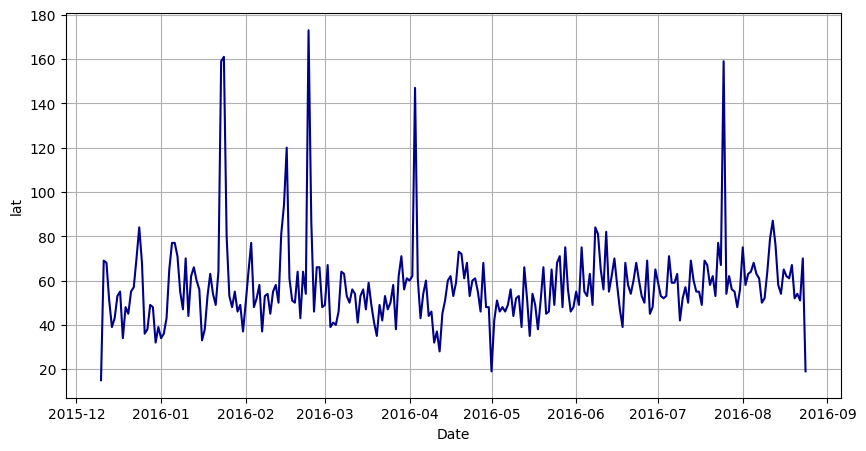

In [27]:
plt.figure(figsize=(10,5))
sns.lineplot(fire_groupby_date,x='Date',y='lat',color='darkblue')
plt.grid()

In [28]:
groupby_weekday_hour=df.groupby(['Hour','Day Of Week']).size().unstack().T
groupby_weekday_hour.head()

Hour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
Day Of Week,,,,,,,,,,,,,,,,,,,,,
Fri,275,235,191,175,201,194,372,598,742,752,...,932,980,1039,980,820,696,667,559,514,474
Mon,282,221,201,194,204,267,397,653,819,786,...,869,913,989,997,885,746,613,497,472,325
Sat,375,301,263,260,224,231,257,391,459,640,...,789,796,848,757,778,696,628,572,506,467
Sun,383,306,286,268,242,240,300,402,483,620,...,684,691,663,714,670,655,537,461,415,330
Thu,278,202,233,159,182,203,362,570,777,828,...,876,969,935,1013,810,698,617,553,424,354


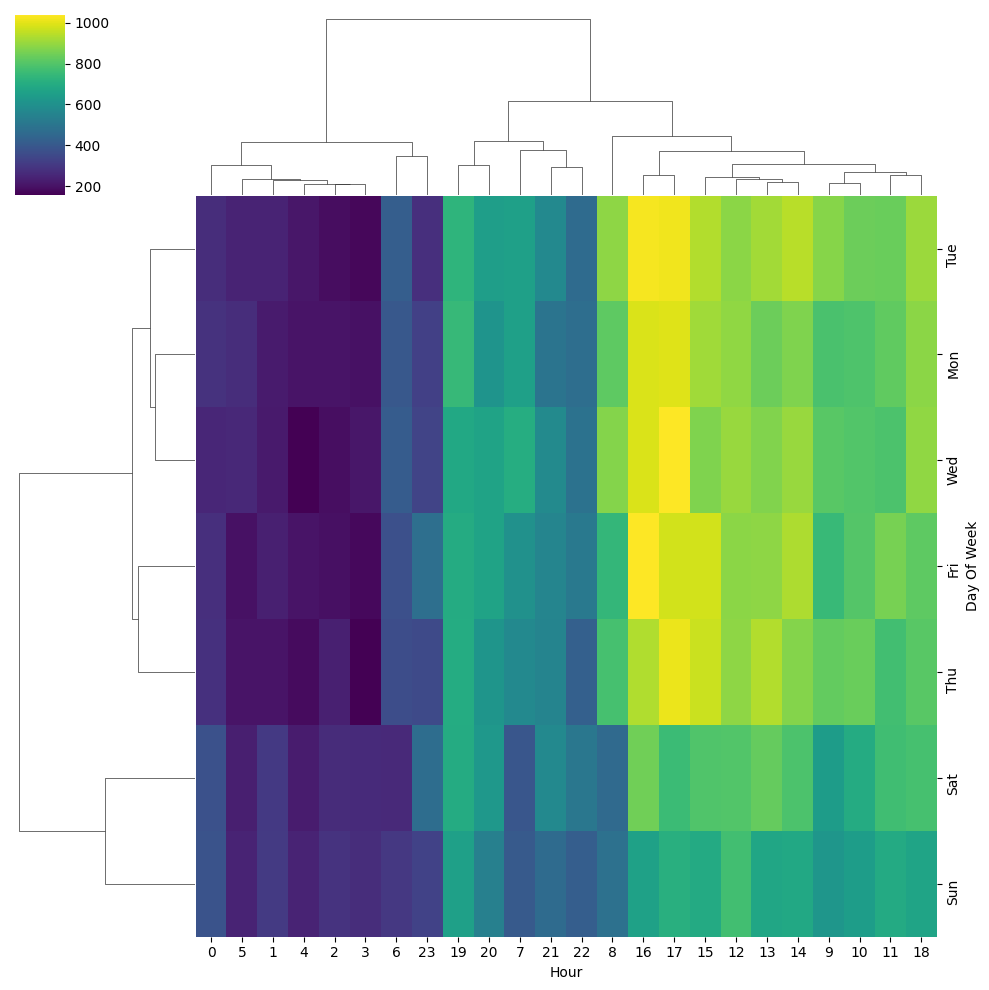

In [29]:
sns.clustermap(groupby_weekday_hour,cmap='viridis')

## Key Findings
- Medical emergencies (EMS) are the dominant reason for 911 calls
- Call volume peaks during daytime hours
- Specific townships consistently generate higher demand
- Temporal patterns are stable, enabling predictive staffing

## Operational Implications
- EMS staffing should be prioritized over other emergency types
- High-demand zipcodes require faster response coverage
- Shift planning can leverage predictable hourly and weekly patterns

## Limitations
- Dataset does not include response times or outcomes
- No population normalization across zipcodes
- Findings reflect historical patterns and may change over time
